<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana11/MinimosCuadradosMatriciales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/MetodosComputacionales2026")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.loadtxt('Semana11/Data/MinimosLineal.txt')
data

array([[ 0.       , -4.786585 ],
       [ 1.052632 , -4.06587  ],
       [ 2.105263 ,  0.1796494],
       [ 3.157895 ,  2.719807 ],
       [ 4.210526 ,  2.878523 ],
       [ 5.263158 ,  4.527426 ],
       [ 6.315789 ,  8.827734 ],
       [ 7.368421 , 10.97722  ],
       [ 8.421053 , 11.79944  ],
       [ 9.473684 , 14.52931  ],
       [10.52632  , 17.22463  ],
       [11.57895  , 21.0981   ],
       [12.63158  , 20.79109  ],
       [13.68421  , 26.08018  ],
       [14.73684  , 26.00302  ],
       [15.78947  , 30.14533  ],
       [16.84211  , 29.14247  ],
       [17.89474  , 33.28434  ],
       [18.94737  , 34.50524  ],
       [20.       , 36.56262  ]])

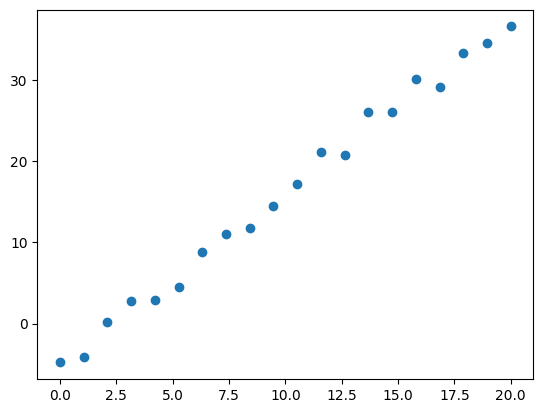

In [4]:
x = data[:,0]
y = data[:,1]
plt.scatter(x,y)

In [5]:
def GetFit(x,y,n=2):

  l = x.shape[0]
  print(l)
  b = y

  A = np.ones((l,n+1))

  for i in range(1,n+1):
    A[:,i] = x**i

  AT = np.dot(A.T,A)
  bT = np.dot(A.T,b)

  xsol = np.linalg.solve(AT,bT)

  return xsol

In [6]:
n = 2
param = GetFit(x,y,n)
param

20


array([-5.45282232e+00,  2.22752179e+00, -5.12424875e-03])

In [7]:
def GetModel(x,p):

  y = 0.
  for n in range(len(p)):
    y += p[n]*x**n

  return y

In [8]:
_x = np.linspace(np.min(x),np.max(x),50)
_y = GetModel(_x,param)

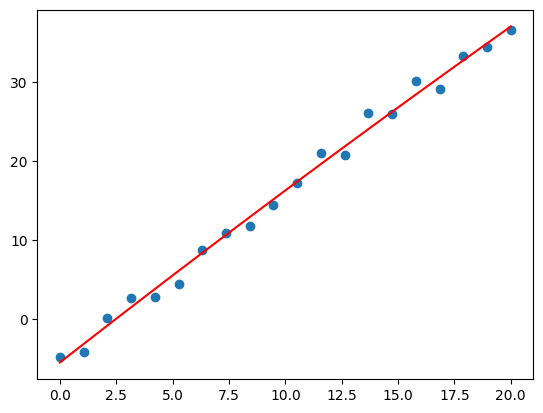

In [9]:
plt.scatter(x,y)
plt.plot(_x,_y,color='r')

In [14]:
Cov = np.random.uniform(size=(2,2))
Cov

array([[0.11614275, 0.2776509 ],
       [0.20382397, 0.2599186 ]])

<Axes: >

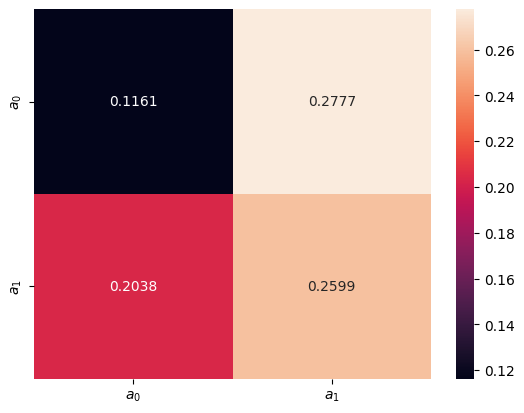

In [15]:
# Etiquetas (puedes cambiarlas según tus parámetros)
labels = [r'$a_{0}$',r'$a_{1}$']

# Crear el heatmap
plt.figure()
sns.heatmap(
    Cov,
    annot=True,        # muestra valores
    fmt=".4f",         # formato decimal
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)